# 4 Pre-Processing and Training Data<a id='4_Pre-Processing_and_Training_Data'></a>

## 4.1 Contents<a id='4.1_Contents'></a>
* [4 Pre-Processing and Training Data](#4_Pre-Processing_and_Training_Data)
  * [4.1 Contents](#4.1_Contents)
  * [4.2 Introduction](#4.2_Introduction)
  * [4.3 Imports](#4.3_Imports)
  * [4.4 Load Data](#4.4_Load_Data)
  * [4.5 Principal Components Analysis](#4.5_Principal_Components_Analysis)
  * [4.6 Train/Test Split](#4.6_Train/Test_Split)
  * [4.7 Scale Dataset](#4.7_Scale_Dataset)
  * [4.8 Linear Regression Models](#4.8_Linear_Regression_Models)
  * [4.9 Random Forest Model](#4.10_Random_Forest_Model)
  * [4.10 Test Models for Second Feature Set_Population_Signal_Removed](#4.10_All_Models)
  * [4.11 Final Models Selection](#4.11_Final_Model_Selection)
  * [4.12 Conclusion](#4.11_Conclusion)
  * [4.13 Save best model object from pipeline](#4.13_Save_best_model_object_from_pipeline)
  * [4.14 Summary](#4.14_Summary)


## 4.2. Introduction<a id='4.2_Introduction'></a>

In the preceding notebooks, we performed exploratory data analysis and determined the features and overall dataset to be used for modeling. We found some missing data for co2, gdp, energy_per_capita features that we handled by dropping the countries entirely or backfilling data for 1 to 2 years.

In this notebook we will do PCA analysis and finalize our feature set, create train/test sets, standardize our data and start building some machine learning models. 

##  4.3 Imports<a id='4.3_Imports'></a>

In [1]:
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import __version__ as sklearn_version
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, learning_curve, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
import statsmodels.api as sm
import statsmodels.formula.api as smf
import datetime
from library.sb_utils import save_file

## 4.4 Load Data<a id='4.4_Load_Data'></a>

In [2]:
co2_data = pd.read_csv('../data/processed/model_ready_data.csv')
co2_data.head()

,country,year,iso_code,log_co2,log_gdp_per_capita,log_energy_per_capita,log_population,log_co2_per_capita
0,Afghanistan,1990,AFG,0.705076,6.989063,7.826789,16.304215,-1.783791
1,Afghanistan,1991,AFG,0.649195,6.891983,6.928611,16.320128,-1.857899
2,Afghanistan,1992,AFG,0.393393,6.861405,6.426577,16.401693,-2.189256
3,Afghanistan,1993,AFG,0.396761,6.489406,6.302176,16.519765,-2.302585
4,Afghanistan,1994,AFG,0.374318,6.188986,6.182800,16.603653,-2.419119


In [3]:
co2_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4853 entries, 0 to 4852
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   country                4853 non-null   object 
 1   year                   4853 non-null   int64  
 2   iso_code               4853 non-null   object 
 3   log_co2                4853 non-null   float64
 4   log_gdp_per_capita     4853 non-null   float64
 5   log_energy_per_capita  4853 non-null   float64
 6   log_population         4853 non-null   float64
 7   log_co2_per_capita     4853 non-null   float64
dtypes: float64(5), int64(1), object(2)
memory usage: 303.4+ KB


## 4.5 Principal Components Analysis<a id='4.5_Principal_Components_Analysis'></a>

In [4]:
#preparing and scaling data for PCA Analysis
features = ['log_gdp_per_capita','log_energy_per_capita','log_population']
X=co2_data[features].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
#perform PCA Analysis
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

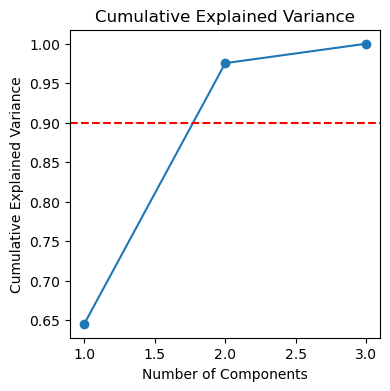

In [6]:
#Cumulative variance plot for PCA Components
cum_var = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize = (4,4))
plt.plot(range(1, len(features)+1), cum_var, marker='o')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(0.9, linestyle='--', color='red')
plt.show()

In [7]:
#pca data summary
pca_dataset = pd.DataFrame(pca.components_, columns=features, 
                            index =[f'PC{i+1}' for i in range(len(features))])
pca_dataset

,log_gdp_per_capita,log_energy_per_capita,log_population
PC1,0.702235,0.704213,-0.104641
PC2,0.093083,0.054901,0.994144
PC3,-0.705834,0.707863,0.026997


We can see from the cumulative explained variance plot and PCA components summary above that PC1 component accounts for more than 70% of the expalined variance and it represents the overall economic and energy development per capita. PC2 seems to be entirely driven by population size and PC3 represents the contrast between energy and gdp per capita.

We did PCA Analysis to understand if we could use PCA components instead of our log features for modeling. Our first PCA component seems to capture majority of the variance pointing to the strong combination of economic and energy features. Our goal is to provide meaningful insights into the drivers of CO2 emissions. Hence, we will not be using PCA components for modeling due to loss of interpretability of key drivers. Multicollinearity was found to be within an acceptable range based on VIF analysis done in exploratory data analysis notebook. Hence, we will proceed with our log features for modeling instead of PCA components.

## 4.6 Train/Test Split<a id='4.6_Train/Test_Split'></a>

Our data is partitioned on country/year and hence we will have to do a time based split for the train and test sets

In [8]:
target = 'log_co2'
num_features = ['log_gdp_per_capita','log_energy_per_capita','log_population']
cat_features = ['country']
data = co2_data.dropna(subset = num_features + cat_features + [target, 'year']).copy()
data = data.sort_values(['country','year'])
train = data[data['year']<=2014].copy()
test = data[data['year']>2014].copy()
X_train = train[num_features + cat_features]
y_train = train[target]
X_test = test[num_features + cat_features]
y_test = test[target]

In [9]:
X_train.shape, X_test.shape

((4043, 4), (810, 4))

In [10]:
y_train.shape, y_test.shape

((4043,), (810,))

In [11]:
#Check the `dtypes` attribute of `X_train` and 'X_test to verify all features are numeric
X_train.dtypes
X_test.dtypes

log_gdp_per_capita       float64
log_energy_per_capita    float64
log_population           float64
country                   object
dtype: object

## 4.7 Scale Dataset<a id='4.7_Scale_Dataset'></a>

In [12]:
scaler = StandardScaler()
train_scaled = train.copy()
test_scaled = test.copy()
train_scaled[num_features]=scaler.fit_transform(train_scaled[num_features])
test_scaled[num_features]=scaler.transform(test_scaled[num_features])

## 4.8 Linear Regression Models<a id='4.8_Linear_Regression_Models'></a>

##### 4.8.1 Ordinary Least Squares Model<a id='4.8.1_Ordinary_Least_Squares_Model'></a>

##### 4.8.1.1 Unscaled Model<a id='4.8.1_Unscaled_Model'></a>

In [13]:
#fixed effect unscaled ols model without cv
#fit the ols model
ols_model = smf.ols('log_co2 ~ log_population + log_gdp_per_capita + log_energy_per_capita + C(country)', data = train).fit()

In [14]:
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                log_co2   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                     3537.
Date:                Fri, 17 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:49:11   Log-Likelihood:                 971.35
No. Observations:                4043   AIC:                            -1613.
Df Residuals:                    3878   BIC:                            -572.4
Df Model:                         164                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [15]:
#predict the model
test['ols_pred'] = ols_model.predict(test)

In [16]:
#evaluate results
rmse = np.sqrt(mean_squared_error(test[target],test['ols_pred']))
print(rmse)

0.26259805954994936


##### 4.8.1.2 Scaled Model<a id='4.8.1_Scaled_Model'></a>

In [17]:
#fixed effect ols model without cv
#fit the ols model
ols_model_scaled = smf.ols('log_co2 ~ log_population + log_gdp_per_capita + log_energy_per_capita + C(country)', data = train_scaled).fit()

In [18]:
print(ols_model_scaled.summary())

                            OLS Regression Results                            
Dep. Variable:                log_co2   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                     3537.
Date:                Fri, 17 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:49:11   Log-Likelihood:                 971.35
No. Observations:                4043   AIC:                            -1613.
Df Residuals:                    3878   BIC:                            -572.4
Df Model:                         164                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [19]:
#predict the model
test_scaled['ols_pred_scaled'] = ols_model_scaled.predict(test_scaled)

In [20]:
#evaluate results
rmse = np.sqrt(mean_squared_error(test_scaled[target],test_scaled['ols_pred_scaled']))
print(rmse)

0.2625980595499515


##### 4.8.2 Ridge Regression Model<a id='4.8.2_Ridge_Regression_Model'></a>

In [21]:
#preprocess columns using scaler and then onehotencoder for categorical features
preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown = 'ignore'), cat_features),
    ]
)

#pipeline for ridge regression model
pipeline_ridge = Pipeline([
        ('preprocessor', preprocessor),
        ('model', Ridge())
])

In [22]:
#crossvalidation and grid search
tscv = TimeSeriesSplit(n_splits=5)
param_grid_ridge = {'model__alpha': [0.1, 1, 10, 50, 100] }
grid_ridge = GridSearchCV(pipeline_ridge, param_grid_ridge, cv=tscv, scoring = 'neg_mean_squared_error', n_jobs=-1)

In [23]:
#Fit Ridge Model and get best params
grid_ridge.fit(X_train, y_train)
print(grid_ridge.best_params_)

{'model__alpha': 10}


In [24]:
ridge_pred = grid_ridge.predict(X_test)

In [25]:
#evaluate results
rmse = np.sqrt(mean_squared_error( y_test, ridge_pred))
print(rmse)

0.23118891972031544


## 4.9 Random Forest Model<a id='4.9_Random_Forest_Model'></a>

In [26]:
#pipeline + grid search
pipeline = Pipeline([('preprocessor', preprocessor), ('model', RandomForestRegressor(random_state=42))])
param_grid= {
            'model__n_estimators': [100,200],
            'model__max_depth': [5,10],
            'model__min_samples_split': [2,5],
            'model__min_samples_leaf': [1,2]
            }

grid_rf = GridSearchCV(pipeline, param_grid, cv = tscv, scoring ='neg_root_mean_squared_error', n_jobs=-1)

In [27]:
#fit model and get best params
grid_rf.fit(X_train, y_train)
print(grid_rf.best_params_)

{'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 100}


In [28]:
#prediction
rf_pred = grid_rf.predict(X_test)

In [29]:
rmse_rf = np.sqrt(mean_squared_error(y_test,rf_pred))
print(rmse_rf)

0.3045871380005723


In [30]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
   grid_rf, X_test, y_test, n_repeats=10, random_state=42
)

perm_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance': perm_importance.importances_mean
}).sort_values(by='importance', ascending=False)

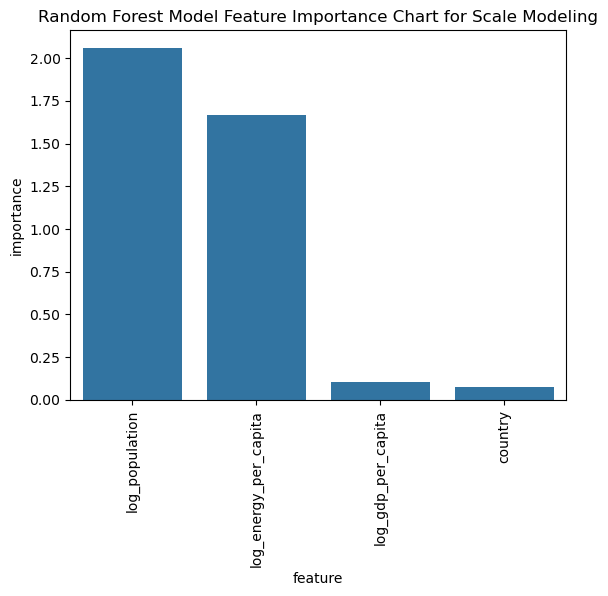

In [31]:
perm_df.head()
sns.barplot(perm_df, x='feature', y='importance')
plt.title("Random Forest Model Feature Importance Chart for Scale Modeling")
plt.xticks(rotation=90)
plt.show()

Permutation Importance for Random Forest Model shows that Population seems to have the strongest impact on CO2 emissions followed by energy per capita and then gdp seems to be having a much lower impact compared to the two. Population being the biggest driver seems to be a bit counterintuite but since we modeled for overall CO2 emissions, it looks like population seems to be acting as a scale variable meaning countries like India, China seem to be dominating the signal.

We will remove the population signal, model for co2 per capita in the next set of models and look at the insights from those models.

## 4.10 Test Models for Second Feature Set_Population_Signal_Removed<a id='All_Models'></a>

In [32]:
#Create Test Train Set
target2 = 'log_co2_per_capita'
num_features2 = ['log_gdp_per_capita','log_energy_per_capita']
cat_features2 = ['country']
data2 = co2_data.dropna(subset = num_features2 + cat_features2 + [target2, 'year']).copy()
data2 = data2.sort_values(['country','year'])
train2 = data2[data2['year']<=2014].copy()
test2 = data2[data2['year']>2014].copy()
X_train2 = train2[num_features2 + cat_features2]
y_train2 = train2[target2]
X_test2 = test2[num_features2 + cat_features2]
y_test2 = test2[target2]

In [33]:
#Ordinary Least Squares Unscaled Model
#fit the ols model
ols_model2 = smf.ols('log_co2_per_capita ~ log_gdp_per_capita + log_energy_per_capita + C(country)', data = train2).fit()
#print ols model summary
print(ols_model2.summary())

                            OLS Regression Results                            
Dep. Variable:     log_co2_per_capita   R-squared:                       0.988
Model:                            OLS   Adj. R-squared:                  0.987
Method:                 Least Squares   F-statistic:                     1927.
Date:                Fri, 17 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:49:41   Log-Likelihood:                 970.46
No. Observations:                4043   AIC:                            -1613.
Df Residuals:                    3879   BIC:                            -579.0
Df Model:                         163                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [34]:
#predict model and get rmse score
test2['ols_pred'] = ols_model2.predict(test2)
rmse = np.sqrt(mean_squared_error(test2[target2],test2['ols_pred']))
print(rmse)

0.2626526490737511


In [35]:
#Ridge Regression Scaled Model
#preprocess columns using scaler and then onehotencoder for categorical features
preprocessor2 = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), num_features2),
        ('cat', OneHotEncoder(handle_unknown = 'ignore'), cat_features2),
    ]
)

#pipeline for ridge regression model
pipeline_ridge2 = Pipeline([
        ('preprocessor2', preprocessor2),
        ('model2', Ridge())
])

#crossvalidation and grid search
tscv2 = TimeSeriesSplit(n_splits=5)
param_grid_ridge2 = {'model2__alpha': [0.1, 1, 10, 50, 100] }
grid_ridge2 = GridSearchCV(pipeline_ridge2, param_grid_ridge2, cv=tscv2, scoring = 'neg_mean_squared_error', n_jobs=-1)

#Fit Ridge Model and get best params
grid_ridge2.fit(X_train2, y_train2)
print(grid_ridge2.best_params_)

{'model2__alpha': 10}


In [36]:
#predict model and get rmse score
ridge_pred2 = grid_ridge2.predict(X_test2)
rmse = np.sqrt(mean_squared_error(test2[target2], ridge_pred2))
print(rmse)

0.23111326800535706


In [37]:
#Random Forest Scaled Model
#pipeline + grid search
pipeline2 = Pipeline([('preprocessor2', preprocessor2), ('model2', RandomForestRegressor(random_state=42))])
param_grid2= {
            'model2__n_estimators': [100,200],
            'model2__max_depth': [5,10],
            'model2__min_samples_split': [2,5],
            'model2__min_samples_leaf': [1,2]
            }

grid_rf2 = GridSearchCV(pipeline2, param_grid2, cv = tscv2, scoring ='neg_root_mean_squared_error', n_jobs=-1)

#fit model and get best params
grid_rf2.fit(X_train2, y_train2)
print(grid_rf2.best_params_)

{'model2__max_depth': 10, 'model2__min_samples_leaf': 2, 'model2__min_samples_split': 2, 'model2__n_estimators': 200}


In [38]:
#predict model and get rmse score
rf_pred2 = grid_rf2.predict(X_test2)
rmse = np.sqrt(mean_squared_error(test2[target2], rf_pred2))
print(rmse)

0.24684455423828386


In [39]:
#Random Forest Permutation Test for Feature Importance
perm_importance2 = permutation_importance(
   grid_rf2, X_test2, y_test2, n_repeats=10, random_state=42
)

perm_df2 = pd.DataFrame({
    'feature': X_test2.columns,
    'importance': perm_importance2.importances_mean
}).sort_values(by='importance', ascending=False)

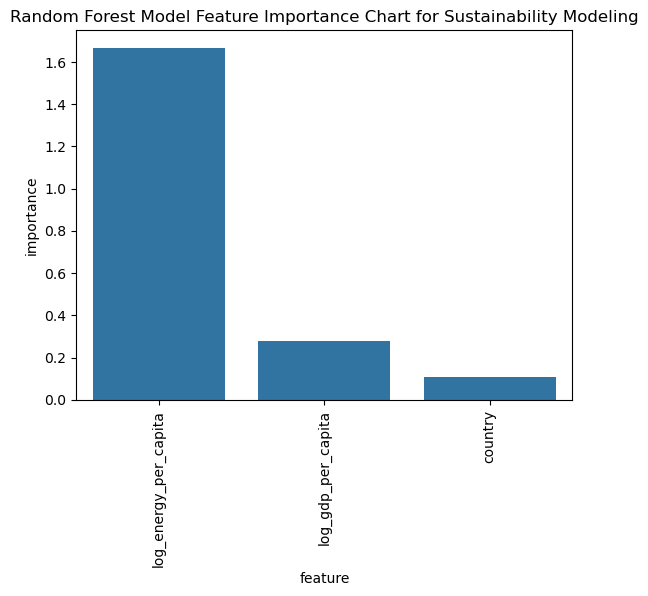

In [40]:
perm_df2.head()
sns.barplot(perm_df2, x='feature', y='importance')
plt.title("Random Forest Model Feature Importance Chart for Sustainability Modeling")
plt.xticks(rotation=90)
plt.show()

Here, we clearly see that CO2 per capita is driven by energy consumption per person followed by moderate impact of gdp per capita and country effect is small meaning differences across countries are largely explained by energy consumption and economic structure.

## 4.11 Final Models Selection<a id='4.11_Final_Model_Selection'></a>

It looks like both sets of models are telling us different stories. First one is for predicting global CO2 emissions with the importance of population signal and hence would be pointing to the dominant countries impacting overall CO2 emissions the most. Second one helps us understand how carbon intensive each country per person is and hence points to efficiency instead of scale (population dominance).  We will be looking at the best performing model from both sets and then finalizing the model to proceed with.

### Model Performance Comparison

In [41]:
#Models Evaluation and Comparison for 1ST Feature Set (Scale Impact)
# define evaluation function

def evaluate(y_test, y_pred, model_name):
    print(f"{model_name}")
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("R2:", r2_score(y_test, y_pred))
    print("-"*30)

evaluate(y_test, test['ols_pred'], "OLS Fixed Effect Model")
evaluate(y_test, test_scaled['ols_pred_scaled'], "OLS Fixed Effect Scaled Model")
evaluate(y_test, ridge_pred, "Ridge Regression Scaled Model")    
evaluate(y_test, rf_pred, "Random Forest Scaled Model")    

OLS Fixed Effect Model
RMSE: 0.26259805954994936
MAE: 0.2005426673742088
R2: 0.9850241940436426
------------------------------
OLS Fixed Effect Scaled Model
RMSE: 0.2625980595499515
MAE: 0.2005426673742088
R2: 0.9850241940436423
------------------------------
Ridge Regression Scaled Model
RMSE: 0.23118891972031544
MAE: 0.16703083260729742
R2: 0.9883924326999473
------------------------------
Random Forest Scaled Model
RMSE: 0.3045871380005723
MAE: 0.20990527845500612
R2: 0.9798520762143954
------------------------------


In [42]:
#Models Evaluation and Comparison for 2nd Feature Set (Sustainability Impact)

evaluate(y_test2, test2['ols_pred'], "OLS Fixed Effect Model")
evaluate(y_test2, ridge_pred2, "Ridge Regression Scaled Model")    
evaluate(y_test2, rf_pred2, "Random Forest Scaled Model")    

OLS Fixed Effect Model
RMSE: 0.2626526490737511
MAE: 0.20060131487115174
R2: 0.969232337350566
------------------------------
Ridge Regression Scaled Model
RMSE: 0.23111326800535706
MAE: 0.16670256791846907
R2: 0.9761778644413016
------------------------------
Random Forest Scaled Model
RMSE: 0.24684455423828386
MAE: 0.18168011301289247
R2: 0.9728244692195558
------------------------------


For both sets, it seems like Ridge Regression Model performs the best for RMSE, MAE and R2. Also, since we are more interested in energy efficiency and sustainability than scale (population dominance) impact we will go ahead with the Ridge model for co2_per_capita as our target variable. 

## 4.12 Conclusion<a id='4.11_Conclusion'></a>

We evaluated Linear Regression Models - OLS, Ridge & then Random Forest Model for two sets of features (one with total CO2 emissions as target variable and another with co2_per_capita. RMSE, MAE and R2 values are best for Ridge Regression Model for both feature sets. We will proceed with Ridge Regression Model for co2_per_capita as our target variable since we are more interested in understaing the impact of energy and gdp (efiiciency and sustainability) compared to population (scale impact).

## 4.13 Save best model object from pipeline<a id='4.12_Save_best_model_object_from_pipeline'></a>

In [43]:
#best model object
best_model = grid_ridge2.best_estimator_
best_model.version = '1.0'
best_model.pandas_version = pd.__version__
best_model.numpy_version = np.__version__
best_model.sklearn_version = sklearn_version
best_model.X_columns = [col for col in X_train2.columns]
best_model.build_datetime = datetime.datetime.now()

In [44]:
print(best_model)

Pipeline(steps=[('preprocessor2',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['log_gdp_per_capita',
                                                   'log_energy_per_capita']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['country'])])),
                ('model2', Ridge(alpha=10))])


In [45]:
# save the model
modelpath = '../models'
save_file(best_model, 'co2_per_capita_insights_model.pkl', modelpath)

A file already exists with this name.



Do you want to overwrite? (Y/N) Y


Writing file.  "../models\co2_per_capita_insights_model.pkl"


## 4.14 Summary<a id='4.13_Summary'></a>

We started by loading the model ready dataset with log features created during Exploratory Data Analysis step. 

1. Principal Components Analysis was done to address multicollinearity on our Standardized features (log_energy_per_capita, log_gdp_per_capita and log_population). The first 1 to 2 features captured majority of the variance. However, since the components were a combination of features, it reduced interpretability. We decided to stick with the original features as they were interpretable, did not have severe multicollinearity and we did not need dimensionality reduction for our dataset because we only had 3 features to begin with.

2. Two modeling strategies were implemented for capturing different perspectives.

* For the first model, log_co2 (total co2 emissions) was our target and features used for modeling were log_population, log_energy_per_capita & log_gdp_per_capita 
This model had a good predictive performance, however population signal dominated all other features as countries like India, China etc. with huge population tend to contribute significantly towards total co2 emissions. So, we had a scale effect with this strategy and it was not very useful for interpreting efficiency.

* For the second model, log_co2_per_capita was our target and log_energy_per_capita and log_gdp_per_capita were our primary features.
This model had higher interpretability as it captured co2 emissions intensity rather than scale and it aligned with sustainability and decoupling analysis.

3. The following models were implemented for both these strategies

* Ordinary Least Squares Model (Scaled and Unscaled) with countries as categorical variables
* Scaled Ridge Regression Model with Hyperparameter Tuning and cross validation
* Random Forest Model with Hyperparameter Tuning, Crossvalidation and permutation importance for feature importance assessment.

4. Train/Test split was done in a time-aware manner.

5. RMSE, MAE and R2 metrics were used for model evaluation.

6. We observed that total co2 models achieved higher R2 due to population dominance whereas co2 per capita models showed slightly lower R2 but greater interpretability. Random Forest model confirmed Energy per capita as the strongest predictor, GDP per capita as secondary with Minimal reliance on country-specific effects for the co2_per_capita model.

7. Modeling results for these strategies showed that while total co2 emissions are largely driven by population size, co2 per capita is primarily determined by energy consumption behavior. This points to the importance of energy efficiency in reducing environmental impact.

8. Hence, we decided to model for co2_per_capita using Ridge Regression model since it performed the best.